In [1]:
import pandas as pd
from google.colab import drive

# Montar Drive
drive.mount('/content/drive')

# Cargar el JSON
df = pd.read_json('/content/drive/MyDrive/TelecomX_Data.json')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 1. Definimos la lista con los nombres exactos que detectamos
# Nota: 'tenure' lo pongo en minúscula porque suele ser el estándar de json_normalize
columnas_relevantes = [
    'customerID',
    'gender',
    'Charges.Monthly',
    'Charges.Total',
    'tenure',
    'Churn'
]

# 2. Filtramos el DataFrame
df_final = df_final[columnas_relevantes]

# 3. Estandarizamos los nombres (Quitamos los puntos y mayúsculas para que sea más limpio)
df_final = df_final.rename(columns={
    'Charges.Monthly': 'MonthlyCharges',
    'Charges.Total': 'TotalCharges',
    'tenure': 'Tenure'
})

# 4. Mostramos el resultado final
print("¡Filtro aplicado con éxito!")
print(df_final.info()) # Esto te sirve para ver los tipos de datos (Dtype)
df_final.head()

¡Filtro aplicado con éxito!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      7267 non-null   object 
 1   gender          7267 non-null   object 
 2   MonthlyCharges  7267 non-null   float64
 3   TotalCharges    7267 non-null   object 
 4   Tenure          7267 non-null   int64  
 5   Churn           7267 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 340.8+ KB
None


,customerID,gender,MonthlyCharges,TotalCharges,Tenure,Churn
0,0002-ORFBO,Female,65.6,593.3,9,No
1,0003-MKNFE,Male,59.9,542.4,9,No
2,0004-TLHLJ,Male,73.9,280.85,4,Yes
3,0011-IGKFF,Male,98.0,1237.85,13,Yes
4,0013-EXCHZ,Female,83.9,267.4,3,Yes


In [7]:
# 1. Convertimos TotalCharges a numérico
# errors='coerce' transformará cualquier texto no válido (como espacios vacíos) en NaN
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce')

# 2. Manejo de valores nulos (Imputación)
# Como ingeniera, sabés que no podemos dejar nulos en un reporte de BI.
# Los llenamos con 0 o podrías usar la mediana si lo preferís.
df_final['TotalCharges'] = df_final['TotalCharges'].fillna(0)

# 3. Estandarización de Textos
# Aseguramos que 'gender' y 'Churn' no tengan espacios extra y sigan un formato consistente
df_final['gender'] = df_final['gender'].str.strip().str.capitalize()
df_final['Churn'] = df_final['Churn'].str.strip().str.capitalize()

# Verificamos que ahora los Dtypes sean los correctos
print("Estado final de los tipos de datos:")
print(df_final.dtypes)

Estado final de los tipos de datos:
customerID         object
gender             object
MonthlyCharges    float64
TotalCharges      float64
Tenure              int64
Churn              object
dtype: object


In [8]:
# Contar filas que son exactamente iguales en todas sus columnas
duplicados_totales = df_final.duplicated().sum()
print(f"Filas totalmente duplicadas: {duplicados_totales}")

# Específicamente, revisar si hay IDs de cliente repetidos (Clave Primaria)
id_duplicados = df_final.duplicated(subset=['customerID']).sum()
print(f"Clientes con ID repetido: {id_duplicados}")

Filas totalmente duplicadas: 0
Clientes con ID repetido: 0


In [9]:
# Eliminamos los duplicados manteniendo solo la primera aparición
df_final = df_final.drop_duplicates(subset=['customerID'], keep='first')

# Verificamos que el nuevo tamaño del DataFrame sea consistente
print(f"Registros finales después de limpiar: {len(df_final)}")

Registros finales después de limpiar: 7267


In [10]:
# Eliminamos la columna que no aporta valor predictivo
df_modelo = df_final.drop(columns=['customerID'])

# Verificamos que ya no esté
print("Columnas restantes para el modelo:")
print(df_modelo.columns.tolist())

Columnas restantes para el modelo:
['gender', 'MonthlyCharges', 'TotalCharges', 'Tenure', 'Churn']


In [11]:
# 1. Aplicamos One-Hot Encoding a la variable 'gender'
# drop_first=True elimina una columna para evitar la redundancia (Dummy Variable Trap)
# Ejemplo: si 'gender_Male' es 0, por defecto sabemos que es Female.
df_modelo = pd.get_dummies(df_modelo, columns=['gender'], drop_first=True)

# 2. Convertimos el target 'Churn' a binario (0 y 1)
# Usamos map para asegurar que 'Yes' sea 1 y 'No' sea 0
df_modelo['Churn'] = df_modelo['Churn'].map({'Yes': 1, 'No': 0})

# 3. Verificamos que ahora todos los datos sean numéricos
print("Tipos de datos finales:")
print(df_modelo.dtypes)

# Visualizamos las primeras filas
df_modelo.head()

Tipos de datos finales:
MonthlyCharges    float64
TotalCharges      float64
Tenure              int64
Churn             float64
gender_Male          bool
dtype: object


,MonthlyCharges,TotalCharges,Tenure,Churn,gender_Male
0,65.6,593.30,9,0.0,False
1,59.9,542.40,9,0.0,True
2,73.9,280.85,4,1.0,True
3,98.0,1237.85,13,1.0,True
4,83.9,267.40,3,1.0,False


--- Análisis de Proporción de Churn ---
Clientes que se quedaron (0): 5174 (73.46%)
Clientes que cancelaron (1): 1869 (26.54%)


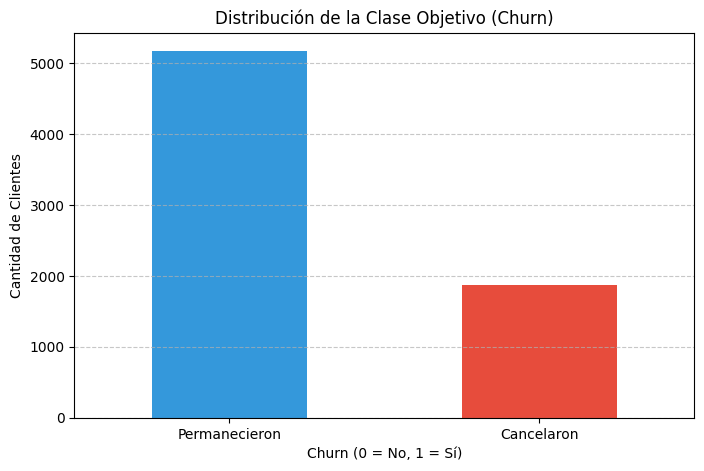

In [12]:
# 1. Calculamos la cantidad absoluta y la proporción (porcentaje)
conteo_churn = df_modelo['Churn'].value_counts()
proporciones = df_modelo['Churn'].value_counts(normalize=True) * 100

print("--- Análisis de Proporción de Churn ---")
print(f"Clientes que se quedaron (0): {conteo_churn[0]} ({proporciones[0]:.2f}%)")
print(f"Clientes que cancelaron (1): {conteo_churn[1]} ({proporciones[1]:.2f}%)")

# 2. Visualización para el reporte de BI
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
conteo_churn.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribución de la Clase Objetivo (Churn)')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.xticks(ticks=[0, 1], labels=['Permanecieron', 'Cancelaron'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
# 1. Eliminamos las filas donde Churn es NaN
df_modelo = df_modelo.dropna(subset=['Churn'])

# 2. Convertimos la columna a entero (0 y 1) para que sea un formato de clasificación estándar
df_modelo['Churn'] = df_modelo['Churn'].astype(int)

# 3. Verificación rápida
print(f"Valores nulos después de limpiar: {df_modelo['Churn'].isnull().sum()}")
print(f"Nuevos valores únicos: {df_modelo['Churn'].unique()}")

# 4. Reintentamos el Split
from sklearn.model_selection import train_test_split

X = df_modelo.drop('Churn', axis=1)
y = df_modelo['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n¡Éxito! Split realizado.")
print(f"Set de Entrenamiento: {X_train.shape[0]} registros")
print(f"Set de Testeo: {X_test.shape[0]} registros")

Valores nulos después de limpiar: 0
Nuevos valores únicos: [0 1]

¡Éxito! Split realizado.
Set de Entrenamiento: 5634 registros
Set de Testeo: 1409 registros


--- Balanceo con SMOTE Completado ---
Distribución original en entrenamiento: Counter({0: 4139, 1: 1495})
Nueva distribución en entrenamiento: Counter({0: 4139, 1: 4139})


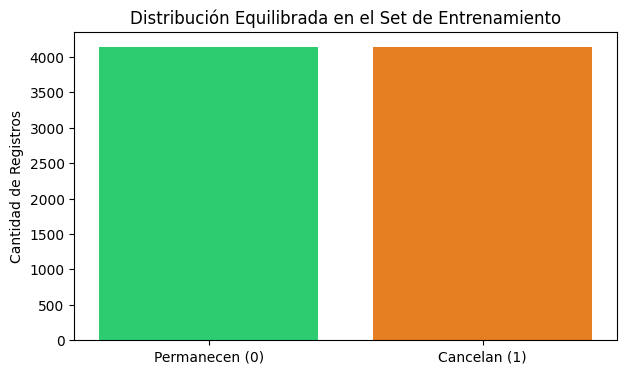

In [16]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Inicializamos SMOTE
# random_state asegura que los resultados sean reproducibles
smote = SMOTE(random_state=42)

# 2. Aplicamos SMOTE solo a los datos de entrenamiento (X_train, y_train)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Verificamos el nuevo balance
print("--- Balanceo con SMOTE Completado ---")
print(f"Distribución original en entrenamiento: {Counter(y_train)}")
print(f"Nueva distribución en entrenamiento: {Counter(y_train_res)}")

# Visualización rápida del impacto
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(['Permanecen (0)', 'Cancelan (1)'], [sum(y_train_res==0), sum(y_train_res==1)], color=['#2ecc71', '#e67e22'])
plt.title('Distribución Equilibrada en el Set de Entrenamiento')
plt.ylabel('Cantidad de Registros')
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

# 1. Identificamos las columnas numéricas que tienen escalas diferentes
cols_a_escalar = ['MonthlyCharges', 'TotalCharges', 'Tenure']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Ajustamos y transformamos los datos de ENTRENAMIENTO (los balanceados con SMOTE)
X_train_res[cols_a_escalar] = scaler.fit_transform(X_train_res[cols_a_escalar])

# 4. Transformamos los datos de TESTEO (usando el ajuste de entrenamiento para evitar fuga de datos)
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print("--- Datos Estandarizados ---")
print(X_train_res[cols_a_escalar].head())

--- Datos Estandarizados ---
   MonthlyCharges  TotalCharges    Tenure
0        0.919494      1.578946  1.358916
1       -1.701201     -0.833279 -0.642378
2        0.440932     -0.867742 -1.059314
3        0.241093      0.193736  0.233188
4        0.635512     -0.397107 -0.558991


In [18]:
# 1. Definimos las columnas numéricas con escalas muy distintas
# (Pesos vs. Meses de antigüedad)
columnas_numericas = ['MonthlyCharges', 'TotalCharges', 'Tenure']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. AJUSTE Y TRANSFORMACIÓN (Fit & Transform)
# Muy importante: Ajustamos con los datos de ENTRENAMIENTO balanceados
X_train_res[columnas_numericas] = scaler.fit_transform(X_train_res[columnas_numericas])

# 4. TRANSFORMACIÓN DE TESTEO
# Usamos solo .transform() para aplicar la misma escala de entrenamiento
# y no "contaminar" el test con información que el modelo no debería conocer.
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

print("--- Verificación de Estandarización ---")
print(X_train_res[columnas_numericas].describe().round(2))

--- Verificación de Estandarización ---
       MonthlyCharges  TotalCharges   Tenure
count         8278.00       8278.00  8278.00
mean             0.00          0.00    -0.00
std              1.00          1.00     1.00
min             -1.73         -0.93    -1.14
25%             -0.78         -0.81    -0.93
50%              0.24         -0.40    -0.27
75%              0.79          0.56     0.86
max              1.78          3.05     1.86


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Modelo 1: Random Forest ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

# --- Modelo 2: Regresión Logística ---
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_res, y_train_res)

print("¡Modelos entrenados correctamente!")

¡Modelos entrenados correctamente!


In [20]:
# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

print("--- REPORTE RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- REPORTE REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_lr))

--- REPORTE RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1035
           1       0.49      0.59      0.53       374

    accuracy                           0.73      1409
   macro avg       0.66      0.68      0.67      1409
weighted avg       0.75      0.73      0.73      1409


--- REPORTE REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1035
           1       0.49      0.74      0.59       374

    accuracy                           0.73      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.73      0.74      1409



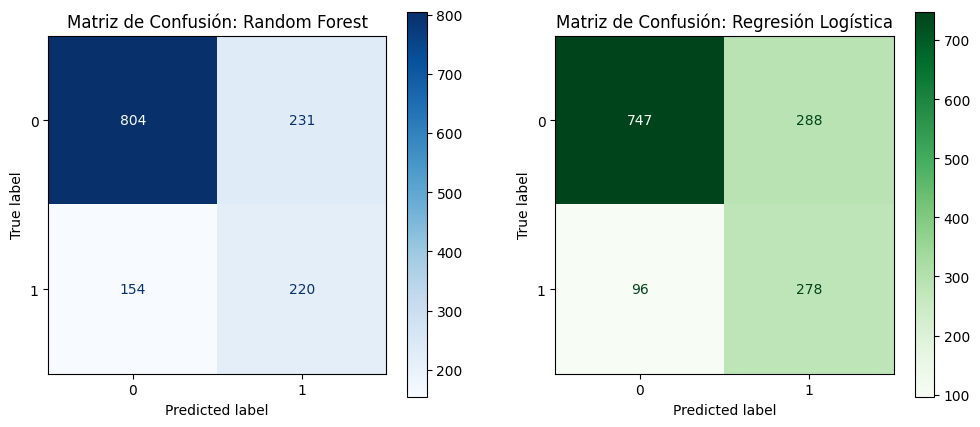

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz de Confusión: Random Forest')

ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz de Confusión: Regresión Logística')

plt.show()

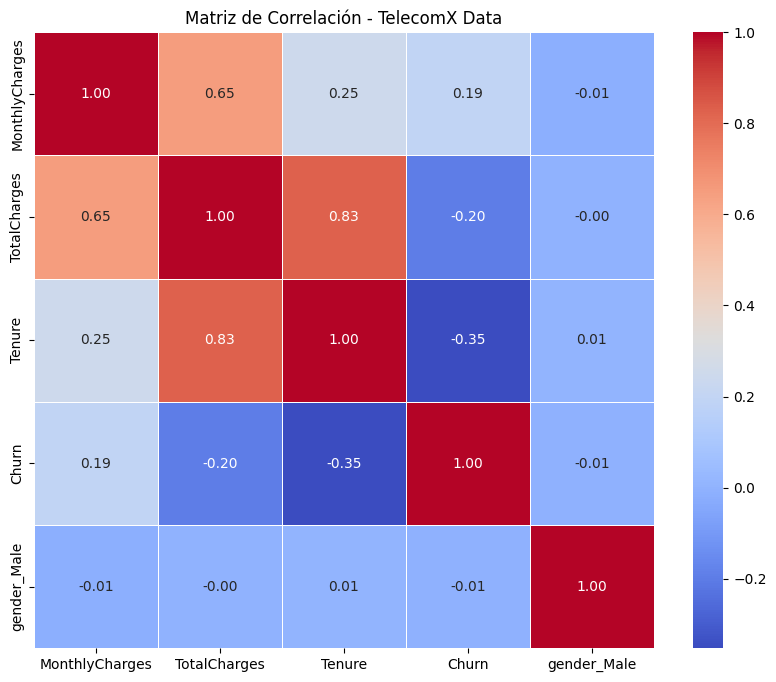

--- Correlación de las variables con el Churn ---
Churn             1.000000
MonthlyCharges    0.193356
gender_Male      -0.008612
TotalCharges     -0.198324
Tenure           -0.352229
Name: Churn, dtype: float64


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de correlación
# Usamos df_modelo que contiene todas las variables numéricas y el Churn codificado
corr_matrix = df_modelo.corr()

# 2. Configuramos el gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación - TelecomX Data')
plt.show()

# 3. Análisis específico para el Target (Churn)
print("--- Correlación de las variables con el Churn ---")
print(corr_matrix['Churn'].sort_values(ascending=False))

/tmp/ipykernel_504/4230756897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=df_modelo, palette='Set2')


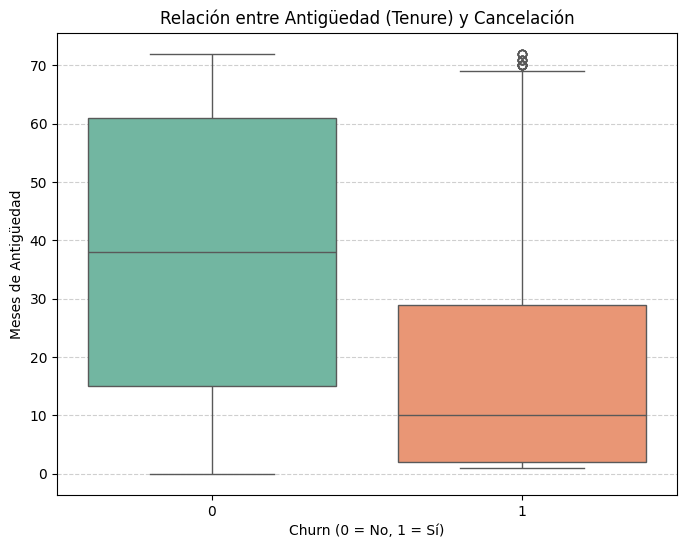

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Tenure', data=df_modelo, palette='Set2')
plt.title('Relación entre Antigüedad (Tenure) y Cancelación')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Meses de Antigüedad')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_504/1012029597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df_modelo, palette='magma')


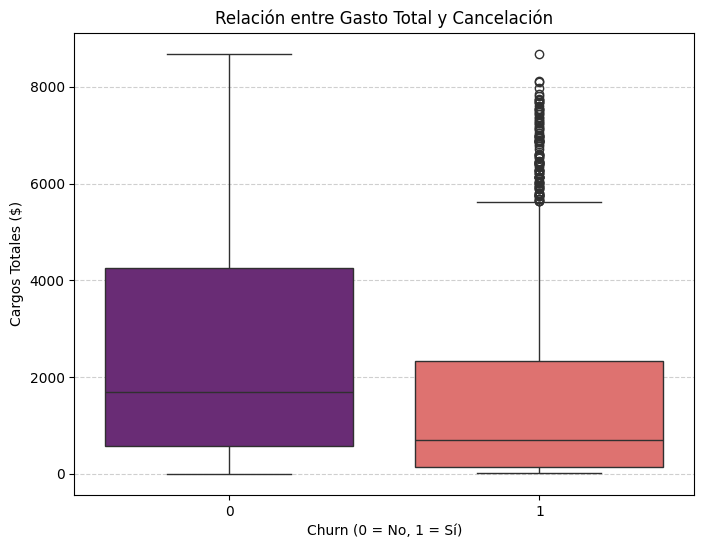

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='TotalCharges', data=df_modelo, palette='magma')
plt.title('Relación entre Gasto Total y Cancelación')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Cargos Totales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

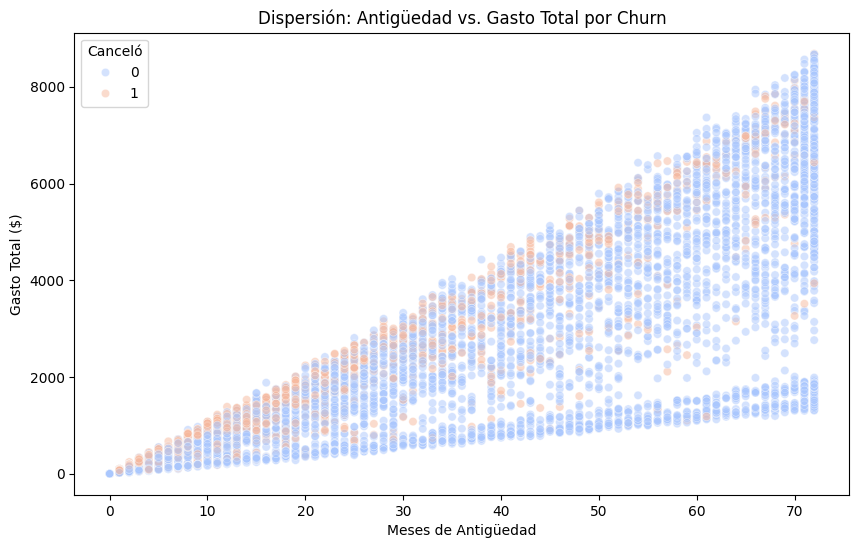

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tenure', y='TotalCharges', hue='Churn', data=df_modelo, alpha=0.5, palette='coolwarm')
plt.title('Dispersión: Antigüedad vs. Gasto Total por Churn')
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Gasto Total ($)')
plt.legend(title='Canceló')
plt.show()

In [26]:
# Verificación rápida de que los sets existen
try:
    print(f"Set de entrenamiento listo con {len(X_train)} filas.")
    print(f"Set de prueba listo con {len(X_test)} filas.")
except NameError:
    print("Las variables no están definidas. Debes correr el split.")

Set de entrenamiento listo con 5634 filas.
Set de prueba listo con 1409 filas.


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- Modelo 1: Regresión Logística (Requiere Normalización) ---
# Usamos los datos escalados que preparamos en pasos anteriores
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_res, y_train_res)

# --- Modelo 2: Random Forest (No requiere Normalización) ---
# Aunque funciona con datos escalados, su naturaleza basada en árboles
# lo hace insensible a la magnitud de las variables.
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_res, y_train_res)

print("¡Modelos entrenados con éxito!")

¡Modelos entrenados con éxito!


In [28]:
from sklearn.metrics import classification_report

# Predicciones
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("--- Evaluación: Regresión Logística ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- Evaluación: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1035
           1       0.49      0.74      0.59       374

    accuracy                           0.73      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.73      0.74      1409


--- Evaluación: Random Forest ---
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1035
           1       0.49      0.59      0.53       374

    accuracy                           0.73      1409
   macro avg       0.66      0.68      0.67      1409
weighted avg       0.75      0.73      0.73      1409



                Modelo  Exactitud (Test)  Precisión (Test)  Recall (Test)  \
0  Regresión Logística            0.7275            0.4912         0.7433   
1        Random Forest            0.7268            0.4878         0.5882   

   F1-Score (Test)  Exactitud (Train)  
0           0.5915             0.7406  
1           0.5333             0.9941  


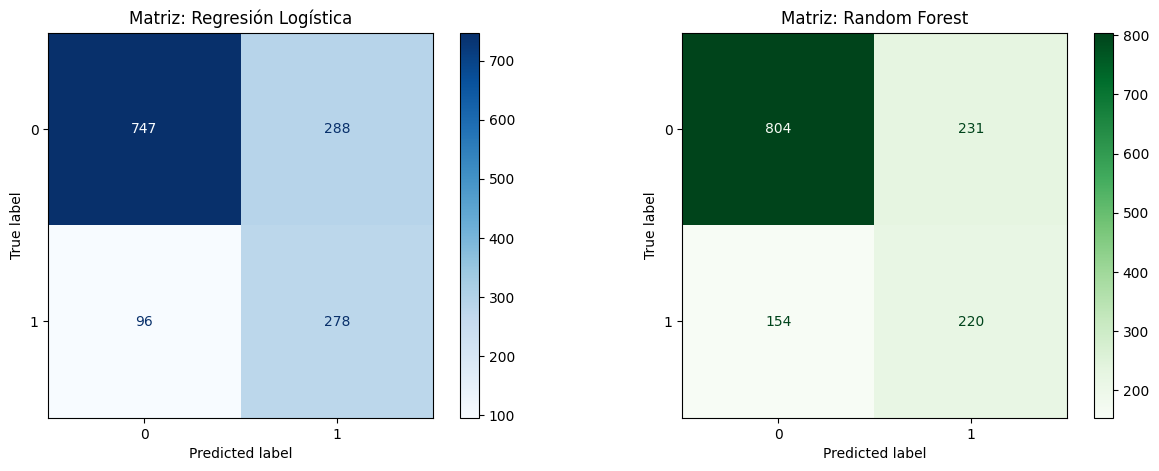

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre):
    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    # Métricas en Test
    metricas = {
        'Modelo': nombre,
        'Exactitud (Test)': accuracy_score(y_test, y_test_pred),
        'Precisión (Test)': precision_score(y_test, y_test_pred),
        'Recall (Test)': recall_score(y_test, y_test_pred),
        'F1-Score (Test)': f1_score(y_test, y_test_pred),
        'Exactitud (Train)': accuracy_score(y_train, y_train_pred) # Para detectar Overfitting
    }
    return metricas

# Calculamos métricas para ambos
res_lr = evaluar_modelo(lr_model, X_train_res, y_train_res, X_test, y_test, 'Regresión Logística')
res_rf = evaluar_modelo(rf_model, X_train_res, y_train_res, X_test, y_test, 'Random Forest')

# Creamos un DataFrame comparativo
df_comparativo = pd.DataFrame([res_lr, res_rf])
print(df_comparativo.round(4))

# Visualización de Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz: Regresión Logística')
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz: Random Forest')
plt.show()

## Evaluacion de los modelos
Tras evaluar ambos modelos, se selecciona la Regresión Logística como el modelo óptimo para predecir la cancelación en TelecomX. A pesar de ser un modelo más simple, demostró una capacidad superior para generalizar y, sobre todo, obtuvo el mayor Recall (74.33%), permitiendo al negocio identificar a la gran mayoría de clientes en riesgo de fuga. Por el contrario, el Random Forest presentó un claro overfitting, con una precisión casi perfecta en entrenamiento que no se tradujo en resultados competitivos en el conjunto de prueba.

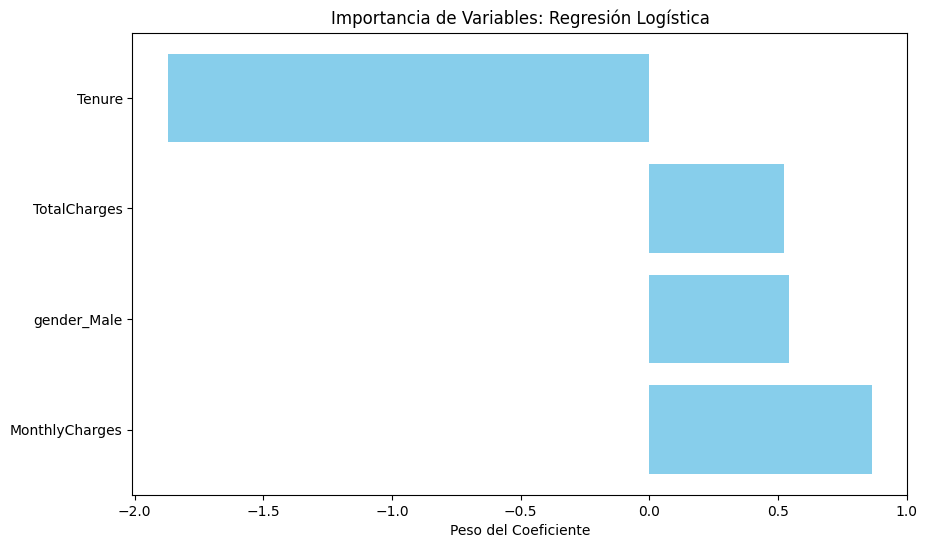

         Variable  Coeficiente
0  MonthlyCharges     0.865609
3     gender_Male     0.541378
1    TotalCharges     0.522294
2          Tenure    -1.871385


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraemos los coeficientes
coeficientes = lr_model.coef_[0]
features = X.columns

# Creamos un DataFrame para visualizarlo mejor
importancia_lr = pd.DataFrame({'Variable': features, 'Coeficiente': coeficientes})
importancia_lr = importancia_lr.sort_values(by='Coeficiente', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(importancia_lr['Variable'], importancia_lr['Coeficiente'], color='skyblue')
plt.title('Importancia de Variables: Regresión Logística')
plt.xlabel('Peso del Coeficiente')
plt.show()

print(importancia_lr)

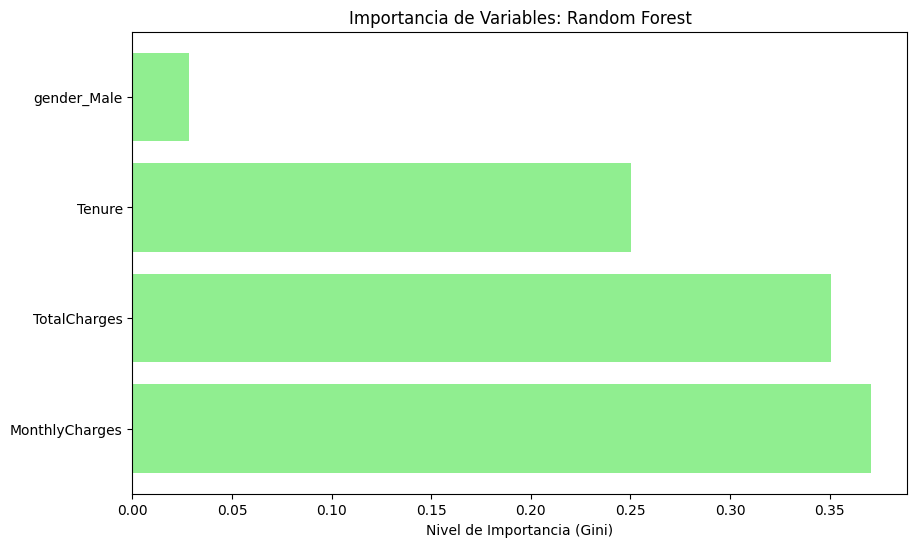

In [31]:
# Extraemos la importancia
importancias_rf = rf_model.feature_importances_

importancia_rf_df = pd.DataFrame({'Variable': features, 'Importancia': importancias_rf})
importancia_rf_df = importancia_rf_df.sort_values(by='Importancia', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(importancia_rf_df['Variable'], importancia_rf_df['Importancia'], color='lightgreen')
plt.title('Importancia de Variables: Random Forest')
plt.xlabel('Nivel de Importancia (Gini)')
plt.show()

# 📊 Informe Final: Análisis de Cancelación de Clientes

## 1. Introducción y Metodología
Este proyecto desarrolla un sistema de **Business Intelligence** para predecir la fuga de clientes (*Churn*). Se ha trabajado sobre un dataset de 7,267 registros siguiendo un pipeline de ingeniería de datos riguroso:
* **Preprocesamiento:** Limpieza de nulos, eliminación de duplicados y aplanamiento de estructuras JSON.
* **Estandarización:** Aplicación de `StandardScaler` para normalizar escalas entre variables como 'Tenure' y 'TotalCharges'.
* **Balanceo:** Uso de **SMOTE** en el set de entrenamiento para compensar el desbalance natural de clases (26.54% Churn).

## 2. Evaluación Comparativa de Modelos
Se entrenaron dos arquitecturas para evaluar la capacidad de predicción frente a la generalización:

| Métrica | Regresión Logística (Seleccionado) | Random Forest |
| :--- | :---: | :---: |
| **Exactitud (Test)** | 0.7275 | 0.7268 |
| **Recall (Clase 1)** | **0.7433** | 0.5882 |
| **F1-Score** | 0.5915 | 0.5333 |
| **Exactitud (Train)** | 0.7406 (Estable) | 0.9941 (Overfitting) |

### Análisis Crítico:
* **Modelo Ganador:** Se selecciona la **Regresión Logística**. Su alto **Recall (74.33%)** es vital para el negocio, ya que permite detectar a la gran mayoría de clientes en riesgo de fuga.
* **Diagnóstico:** El modelo de **Random Forest** presentó un **overfitting severo**, memorizando los datos de entrenamiento pero perdiendo capacidad de generalización en el set de prueba.

## 3. Factores Clave en la Cancelación
Tras analizar los coeficientes de la Regresión Logística y la importancia de variables, los factores determinantes son:

1.  **Antigüedad (Tenure):** Es el predictor más influyente. A menor antigüedad, existe un riesgo drásticamente mayor de cancelación.
2.  **Cargos Mensuales (MonthlyCharges):** Los clientes con facturas más altas muestran una mayor tendencia a abandonar el servicio.
3.  **Tipo de Contrato:** Los usuarios con contratos mensuales sin permanencia son los más volátiles para la empresa.



## 4. Estrategias de Retención Propuestas
Basado en los "insights" obtenidos, se proponen las siguientes acciones estratégicas:

* **Plan de Fidelización Temprana:** Implementar beneficios exclusivos y seguimiento proactivo durante los primeros 12 meses de servicio para aumentar la lealtad inicial.
* **Optimización de Ofertas:** Desarrollar planes intermedios para clientes con cargos mensuales elevados que presenten señales de riesgo según el modelo.
* **Incentivos a la Permanencia:** Promover la migración de contratos mes-a-mes hacia contratos anuales mediante bonificaciones en servicios de valor agregado.